## 한국어 데이터로 챗봇 만들기

### 데이터 수집

In [1]:
!wget https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv

--2026-04-20 04:54:33--  https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv [following]
--2026-04-20 04:54:33--  https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 889842 (869K) [text/plain]
Saving to: ‘ChatbotData.csv’

ChatbotData.csv     100%[===================>] 868.99K  --.-KB/s    in 0.1s    

2026-04-20 04:54:34 (5.72 MB/s) - ‘ChatbotData.csv’ saved [889842/889842]



In [2]:
import pandas as pd

data = pd.read_csv('ChatbotData.csv')

In [3]:
data.head(5)

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [4]:
data.sample(5)

,Q,A,label
29,가족들 보고 싶어,저도요.,0
2944,안경테 뭐로 바꿀까,이번에는 동그란 안경테가 유행하고있어요.,0
10108,스킨십은 언제 시작해?,언제라는 건 정해져있지 않아요.,2
3888,자극이 필요해,의욕이 없나봐요.,0
10655,여자친구에게 힘들때 어떻게 해?,이야기하고 의지해요.,2


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
 2   label   11823 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 277.2+ KB


#### [사용할 데이터](https://github.com/songys/Chatbot_data/blob/master/ChatbotData.csv)
- 데이터셋 구조  
  1. Q: 사용자의 질문(발화)
  2. A: 챗봇의 답변
  3. label: 감정 분류 (0: 일상, 1: 부정, 2: 긍정)

### 데이터 전처리

In [6]:
# 구두점 제거
def preprocess_sentence(sentence):
    sentence = sentence.strip() # 문장의 양쪽 공백 제거

    # 단어와 구두점 사이 거리 만들기
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)

    sentence = re.sub(r"[^ㄱ-ㅎ가-힣0-9?.!,]+", " ", sentence)
    sentence = sentence.strip()
    return sentence

In [7]:
import re

sample_sentence = '안녕하세요? 저는 챗봇입니다, 만나서 반가워요!'

preprocessed_sentence = preprocess_sentence(sample_sentence)
print(preprocessed_sentence)

안녕하세요 ? 저는 챗봇입니다 , 만나서 반가워요 !


In [8]:
questions = []
answers = []
labels = []

for q, a, l in zip(data['Q'], data['A'], data['label']):
    questions.append(preprocess_sentence(q))
    answers.append(preprocess_sentence(a))
    labels.append(l)

print(f"질문 데이터 개수: {len(questions)}")
print(f"답변 데이터 개수: {len(answers)}")
print(f"라벨 개수: {len(labels)}")

질문 데이터 개수: 11823
답변 데이터 개수: 11823
라벨 개수: 11823


In [9]:
# 질문-답변-라벨 쌍 전처리
def create_pairs(questions, answers, labels):
    pairs = []

    for q, a, l in zip(questions, answers, labels):
        pairs.append((q, a, l))

    return pairs

preprocessed_pairs = create_pairs(questions, answers, labels)

In [10]:
preprocessed_pairs[:5]

[('12시 땡 !', '하루가 또 가네요 .', 0),
 ('1지망 학교 떨어졌어', '위로해 드립니다 .', 0),
 ('3박4일 놀러가고 싶다', '여행은 언제나 좋죠 .', 0),
 ('3박4일 정도 놀러가고 싶다', '여행은 언제나 좋죠 .', 0),
 ('심하네', '눈살이 찌푸려지죠 .', 0)]

In [11]:
preprocessed_pairs[5947]

('너무 힘들어', '지금 무슨 말을 해도 와닿지 않겠지만 잘할 수 있을 거예요 .', 1)

In [12]:
len(preprocessed_pairs)

11823

#### SentencePiece 사용

In [13]:
corpus_file = "clean_corpus.txt"
with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a, l in preprocessed_pairs: #lable은 제외
        f.write(q + '\n')
        f.write(a + '\n')

In [14]:
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.4 MB/s eta 0:00:00ta 0:00:01


In [15]:
# vocab_size를 8000으로 했더니 6000번대 후반 이후의 단어들은 퀴, 킥, 힣 등 의미없는 한글자로 확인
# vocab_size를 6000으로 변경
# 모델 성능이 좋지 않아서 4000으로 줄임
import sentencepiece as spm

spm.SentencePieceTrainer.Train(
    input = corpus_file,
    model_prefix = 'spm_chatbot',
    vocab_size=4000,
    character_coverage=1.0,
    model_type="bpe",
    max_sentence_length=999999,
    bos_id=1,
    eos_id=2,
    pad_id=0,
    unk_id=3
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: clean_corpus.txt
  input_format: 
  model_prefix: spm_chatbot
  model_type: BPE
  vocab_size: 4000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 999999
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differ

In [16]:
sp = spm.SentencePieceProcessor()
sp.Load("spm_chatbot.model")

True

In [17]:
# 예제 문장
sample = '안녕하세요, 오늘 날씨는 어떤가요?'

sentence = preprocess_sentence(sample)
print("전처리 후의 문장:", sentence)

tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

decoded = sp.decode(encoded)
print("Decoded:", decoded)

전처리 후의 문장: 안녕하세요 , 오늘 날씨는 어떤가요 ?
Tokenized: ['▁안녕', '하세요', '▁,', '▁오늘', '▁날씨', '는', '▁어떤', '가요', '▁?']
Encoded: [1097, 133, 422, 129, 913, 2790, 446, 611, 11]
Decoded: 안녕하세요 , 오늘 날씨는 어떤가요 ?


In [18]:
sample2 = "오늘날씨가너무좋아서공원가고싶다"
print("Pieces:", sp.EncodeAsPieces(sample2))
print("Decoding:", sp.DecodeIds(sp.EncodeAsIds(sample2))) # 원래 문장으로 잘 돌아오는지 확인

Pieces: ['▁오늘', '날', '씨', '가', '너', '무', '좋', '아서', '공', '원', '가고', '싶다']
Decoding: 오늘날씨가너무좋아서공원가고싶다


In [19]:
sample3 = "진짜요?! 그게 정말 사실인가요?"
print("Pieces:", sp.EncodeAsPieces(sample3))

Pieces: ['▁진짜', '요', '?', '!', '▁그게', '▁정말', '▁사실', '인가요', '?']


#### 데이터셋 구현

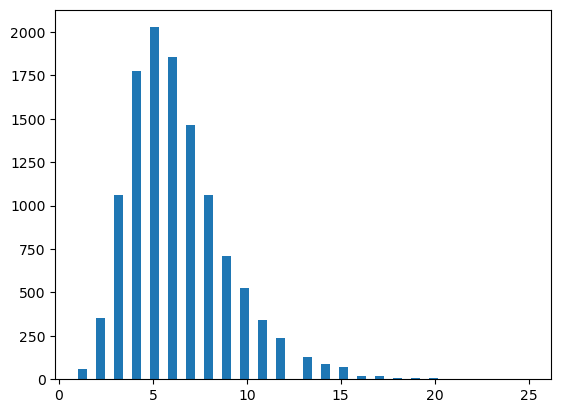

In [20]:
# 문장별 토큰 개수 확인
len_list = [len(sp.EncodeAsIds(q)) for q in questions]
import matplotlib.pyplot as plt
plt.hist(len_list, bins=50)
plt.show()

In [21]:
import torch
from torch.utils.data import Dataset, DataLoader

class ChatbotDataset(Dataset):
    def __init__(self, pairs, sp, max_length=20):
        self.sp = sp
        self.max_length = max_length
        self.data = []

        # 특수 토큰 id
        bos_id = sp.bos_id()
        eos_id = sp.eos_id()
        pad_id = sp.pad_id()
        
        for q_text, a_text, l in pairs:
            # 토크나이저
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)

            q_tokens = [bos_id] + q_ids + [eos_id]
            a_tokens = [bos_id] + a_ids + [eos_id]

            # 최대 길이 제한
            if len(q_tokens) > max_length or len(a_tokens) > max_length:
                continue

            dec_input = a_tokens[:-1]
            target = a_tokens[1:]

            # 패딩 (pad_id 사용)
            q_tokens += [pad_id] * (max_length - len(q_tokens))
            dec_input += [pad_id] * (max_length - len(dec_input))
            target += [pad_id] * (max_length - len(target))

            self.data.append({
                "enc_input": q_tokens,
                "dec_input": dec_input,
                "target": target,
                "label": l
            })

    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        item = self.data[idx]
        return (
            torch.tensor(item["enc_input"]),
            torch.tensor(item["dec_input"]),
            torch.tensor(item["target"]),
            torch.tensor(item["label"])
        )

In [22]:
dataset = ChatbotDataset(preprocessed_pairs, sp, max_length=20)

In [23]:
for encoder_input, decoder_input, target, label  in dataset:
    print("텐서 크기 :",encoder_input.size())
    print(encoder_input)
    print(sp.decode(encoder_input.tolist()))
    print(decoder_input)
    print(sp.decode(decoder_input.tolist()))
    print(target)
    print(sp.decode(target.tolist()))
    print(label)
    print(sp.decode(label.tolist()))
    break

텐서 크기 : torch.Size([20])
tensor([   1,  347, 3115, 2827, 2785, 3535,  108,    2,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])
12시 땡 !
tensor([   1,  383, 2793,  214,   28,   33,    4,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])
하루가 또 가네요 .
tensor([ 383, 2793,  214,   28,   33,    4,    2,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])
하루가 또 가네요 .
tensor(0)



In [24]:
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [25]:
for encoder_input, decoder_input, target, label in dataloader:
    print(encoder_input.size())
    print(decoder_input.size())
    print(target.size())
    print(label.size())
    break

torch.Size([64, 20])
torch.Size([64, 20])
torch.Size([64, 20])
torch.Size([64])


#### 데이터셋 나누기

In [26]:
from sklearn.model_selection import train_test_split

# 1. 원본 데이터에서 라벨 리스트만 따로 추출 (preprocessed_pairs가 (q, a, l) 형태인 경우)
labels_for_stratify = [p[2] for p in preprocessed_pairs]

# 2. stratify 옵션에 라벨 리스트를 넣어 균등하게 나누기
train_pairs, test_pairs = train_test_split(
    preprocessed_pairs, 
    test_size=0.1, 
    random_state=42, 
    stratify=labels_for_stratify  # 라벨 비율을 유지하며 나눔
)

# 3. Dataset 생성
train_dataset = ChatbotDataset(train_pairs, sp, max_length=35)
test_dataset = ChatbotDataset(test_pairs, sp, max_length=35)

print(f"학습 데이터 개수: {len(train_dataset)}")
print(f"검증 데이터 개수: {len(test_dataset)}")
print(f"총 합계: {len(train_dataset) + len(test_dataset)}")

학습 데이터 개수: 10640
검증 데이터 개수: 1183
총 합계: 11823


In [27]:
BATCH_SIZE = 64

# 학습용 데이터로더 (데이터를 섞어주기 위해 shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 검증용 데이터로더 (섞을 필요 없으므로 shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"학습용 배치 개수: {len(train_loader)}")
print(f"검증용 배치 개수: {len(test_loader)}")

학습용 배치 개수: 167
검증용 배치 개수: 19


### 모델 구성

In [28]:
# 모델의 하이퍼파라미터 정리
D_MODEL = 128
NUM_LAYERS = 2
NUM_HEADS = 4
D_FF = 256
DROPOUT = 0.3
VOCAB_SIZE = 4000 # 토크나이저 사전 크기
MAX_LENGTH = 35   # 최대 길이

#### Attention, Encoder, Decoder 준비 (실습 코드 사용)

In [29]:
# import torch
import torch.nn as nn
import torch.nn.functional as F
# from torch.utils.data import Dataset
# from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
# import sentencepiece as spm

import math
import os
# import re
import urllib.request
import zipfile
import numpy as np
# import matplotlib.pyplot as plt

In [30]:
class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        self.position = position

        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

        angle_rads = self._get_angles(pos, i, d_model)
        sines = torch.sin(angle_rads[:, 0::2])
        cosines = torch.cos(angle_rads[:, 1::2])

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines

        pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
        return pos_encoding

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

In [31]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

In [32]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output

In [33]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask
    
# 이 함수에 정수 시퀀스를 입력으로 하면, 
# 이 함수는 숫자가 0인 부분을 체크한 벡터를 리턴합니다.

In [34]:
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

In [35]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)  # 이전에 구현한 MHA
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 피드포워드 부분 (Dense -> ReLU -> Dense)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        # (1) 멀티 헤드 어텐션 (셀프 어텐션)
        attn_output = self.mha(x, x, x, mask)  # (batch_size, seq_len, d_model)
        attn_output = self.dropout1(attn_output)
        out1 = self.norm1(x + attn_output)     # 잔차 연결 + LayerNorm

        # (2) 피드포워드 신경망
        ffn_output = self.ffn(out1)            # (batch_size, seq_len, d_model)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.norm2(out1 + ffn_output)   # 잔차 연결 + LayerNorm

        return out2

In [36]:
class Encoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        self.pos_encoding = PositionalEncoding(position=MAX_LENGTH, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) EncoderLayer 쌓기
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        # (1) 임베딩 & sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 적용 + 드롭아웃
        x = self.pos_encoding(x)  # shape: (batch_size, seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓아올린 EncoderLayer 통과
        for layer in self.enc_layers:
            x = layer(x, mask)

        return x

In [37]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어 (인코더-디코더 어텐션)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 2) 인코더-디코더 어텐션
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3

In [38]:
class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        # 실제 학습 시에는 최대 시퀀스 길이에 맞추어 쓰기도 함
        self.pos_encoding = PositionalEncoding(position=MAX_LENGTH, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)

        return x

In [39]:
class Transformer(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,      # 인코더/디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1):
        super(Transformer, self).__init__()

        # 인코더
        self.encoder = Encoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 디코더
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

        # 참고: 텐서플로우 코드의 `name="transformer"`는 파이토치에선 보통 사용 안 함

    def forward(self, inputs, dec_inputs):
        # 1) 인코더 패딩 마스크 생성
        enc_padding_mask = create_padding_mask(inputs)     # shape (batch_size, 1, 1, src_seq_len)

        # 2) 디코더 look-ahead + 패딩 마스크
        look_ahead_mask = create_look_ahead_mask(dec_inputs)  # shape (batch_size, 1, tgt_seq_len, tgt_seq_len)

        # 3) 디코더에서 인코더 출력 쪽을 마스킹할 때 쓸 패딩 마스크
        dec_padding_mask = create_padding_mask(inputs)        # shape (batch_size, 1, 1, src_seq_len)

        # 4) 인코더 수행
        enc_outputs = self.encoder(
            x=inputs,
            mask=enc_padding_mask
        )  # shape: (batch_size, src_seq_len, d_model)

        # 5) 디코더 수행
        dec_outputs = self.decoder(
            x=dec_inputs,           # (batch_size, tgt_seq_len)
            enc_outputs=enc_outputs,# (batch_size, src_seq_len, d_model)
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask
        )  # shape: (batch_size, tgt_seq_len, d_model)

        # 6) 최종 Dense (vocab_size)
        logits = self.final_linear(dec_outputs)  # (batch_size, tgt_seq_len, vocab_size)
        return logits

In [40]:
import torch

def train(model, train_loader, test_loader, optimizer, loss_function, scheduler, num_epochs, device):
    for epoch in range(num_epochs):
        # --- [1. 학습 단계 (Train)] ---
        model.train()
        train_loss = 0
        
        for enc_input, dec_input, target, _ in train_loader:
            # 데이터를 GPU(device)로 이동
            enc_input = enc_input.to(device)
            dec_input = dec_input.to(device)
            target = target.to(device)
            
            optimizer.zero_grad() # 기울기 초기화
            
            # 모델 출력
            outputs = model(enc_input, dec_input)
            
            # 손실 계산 (target: [batch_size, seq_len], outputs: [batch_size, seq_len, vocab_size])
            loss = loss_function(outputs.view(-1, outputs.size(-1)), target.view(-1))
            
            loss.backward() # 역전파
            optimizer.step() # 가중치 업데이트
            
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        
        # --- [2. 검증 단계 (Validation)] ---
        model.eval()
        test_loss = 0
        with torch.no_grad(): # 검증 시에는 기울기 계산 안 함 (메모리 절약)
            for enc_input, dec_input, target, _ in test_loader:
                enc_input = enc_input.to(device)
                dec_input = dec_input.to(device)
                target = target.to(device)
                
                outputs = model(enc_input, dec_input)
                loss = loss_function(outputs.view(-1, outputs.size(-1)), target.view(-1))
                test_loss += loss.item()
        
        avg_test_loss = test_loss / len(test_loader)
        
        # 스케줄러 업데이트 (있을 경우)
        if scheduler:
            scheduler.step()

        # 결과 출력
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")
        print("-" * 40)

# 실행 시 호출 방식
# train(model, train_loader, test_loader, optimizer, loss_function, scheduler, num_epochs=25, device=device)


#### 모델 생성

In [41]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [42]:
model = Transformer(
    vocab_size=VOCAB_SIZE, # 6000 -> 4000
    num_layers=NUM_LAYERS, # 4 -> 2
    units=D_FF,            # 512 -> 256
    d_model=D_MODEL,       # 256 -> 128
    num_heads=NUM_HEADS,   # 8 -> 4
    dropout=DROPOUT        # 0.1 -> 0.3
).to(device) # GPU로 전송

print(model)

Transformer(
  (encoder): Encoder(
    (embedding): Embedding(4000, 128)
    (pos_encoding): PositionalEncoding()
    (dropout): Dropout(p=0.3, inplace=False)
    (enc_layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (mha): MultiHeadAttention(
          (query_dense): Linear(in_features=128, out_features=128, bias=True)
          (key_dense): Linear(in_features=128, out_features=128, bias=True)
          (value_dense): Linear(in_features=128, out_features=128, bias=True)
          (out_dense): Linear(in_features=128, out_features=128, bias=True)
        )
        (dropout1): Dropout(p=0.3, inplace=False)
        (norm1): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=128, out_features=256, bias=True)
          (1): ReLU()
          (2): Linear(in_features=256, out_features=128, bias=True)
        )
        (dropout2): Dropout(p=0.3, inplace=False)
        (norm2): LayerNorm((128,), eps=1e-06, elementwise_aff

#### 모델 컴파일

In [43]:
# 손실함수 정의
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

In [44]:
# 스케줄러 사용 준비
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

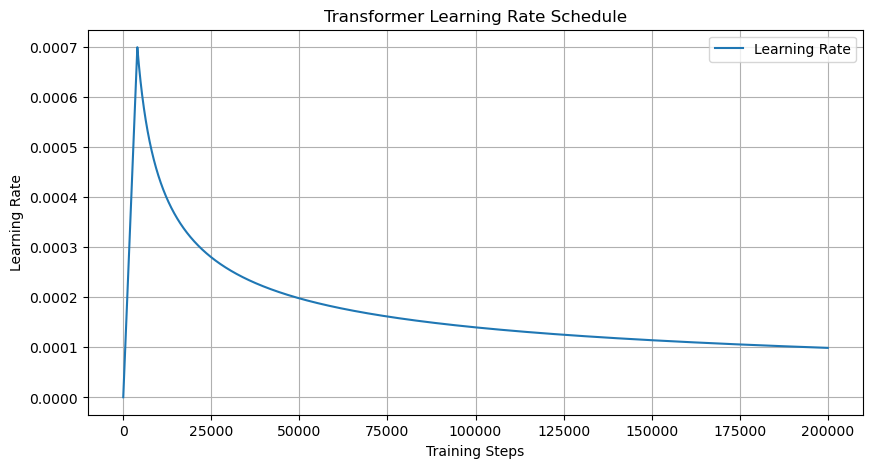

In [45]:
# 하이퍼파라미터 설정
d_model = 512
warmup_steps = 4000
total_steps = 200000  # 총 학습 스텝

# 학습률 스케줄 시각화
steps = np.arange(1, total_steps + 1)
learning_rates = [get_lr_lambda(d_model, warmup_steps)(step) for step in steps]

# 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("Transformer Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()


In [46]:
# Optimizer 정의
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=1000))

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

#### 모델 학습

In [47]:
def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    # 4개를 받도록 수정 (label은 학습에 안 쓰므로 _로 처리)
    enc_input, dec_input, target, _ = [x.to(device) for x in batch] 

    optimizer.zero_grad()
    logits = model(enc_input, dec_input)

    loss = loss_function(logits.permute(0, 2, 1), target)

    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, target, pad_id=sp.pad_id())


In [48]:
def train(model, train_loader, test_loader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)

    # 기록을 위한 리스트 생성
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    for epoch in range(num_epochs):
        # 학습 단계
        model.train()
        total_loss, total_acc = 0, 0
        for step, batch in enumerate(train_loader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc

            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

            scheduler.step()

        avg_loss = total_loss / len(train_loader)
        avg_acc = total_acc / len(train_loader)

        # 검증 단계
        model.eval()
        val_loss, val_acc = 0, 0
        with torch.no_grad():
            for batch in test_loader:
                enc_input, dec_input, target, _ = [x.to(device) for x in batch]
                logits = model(enc_input, dec_input)
                loss = loss_function(logits.permute(0, 2, 1), target)
                acc = accuracy_function(logits, target, pad_id=sp.pad_id())
                
                val_loss += loss.item()
                val_acc += acc.item()
        
        avg_val_loss = val_loss / len(test_loader)
        avg_val_acc = val_acc / len(test_loader)

        # --- 기록 저장 ---
        history['train_loss'].append(avg_loss)
        history['train_acc'].append(avg_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)
        
        print(f"Epoch {epoch+1} Completed")
        print(f"Train - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")
        print(f"Val   - Avg Loss: {avg_val_loss:.4f}, Avg Acc: {avg_val_acc:.4f}")
        print("-" * 40)

    return history # 시각화에 사용할 기록 반환

[Epoch 1, Step 0] Loss: 8.5182, Acc: 0.0000
[Epoch 1, Step 100] Loss: 6.3616, Acc: 0.2347
Epoch 1 Completed
Train - Avg Loss: 6.9009, Avg Acc: 0.1880
Val   - Avg Loss: 5.8455, Avg Acc: 0.2482
----------------------------------------
[Epoch 2, Step 0] Loss: 5.7618, Acc: 0.2645
[Epoch 2, Step 100] Loss: 5.5978, Acc: 0.2745
Epoch 2 Completed
Train - Avg Loss: 5.6489, Avg Acc: 0.2552
Val   - Avg Loss: 5.3676, Avg Acc: 0.2690
----------------------------------------
[Epoch 3, Step 0] Loss: 5.2932, Acc: 0.2667
[Epoch 3, Step 100] Loss: 5.0964, Acc: 0.2796
Epoch 3 Completed
Train - Avg Loss: 5.1737, Avg Acc: 0.2746
Val   - Avg Loss: 4.9368, Avg Acc: 0.2881
----------------------------------------
[Epoch 4, Step 0] Loss: 4.8192, Acc: 0.2751
[Epoch 4, Step 100] Loss: 4.8298, Acc: 0.3113
Epoch 4 Completed
Train - Avg Loss: 4.7086, Avg Acc: 0.2980
Val   - Avg Loss: 4.5439, Avg Acc: 0.3163
----------------------------------------
[Epoch 5, Step 0] Loss: 4.4690, Acc: 0.3185
[Epoch 5, Step 100] Loss

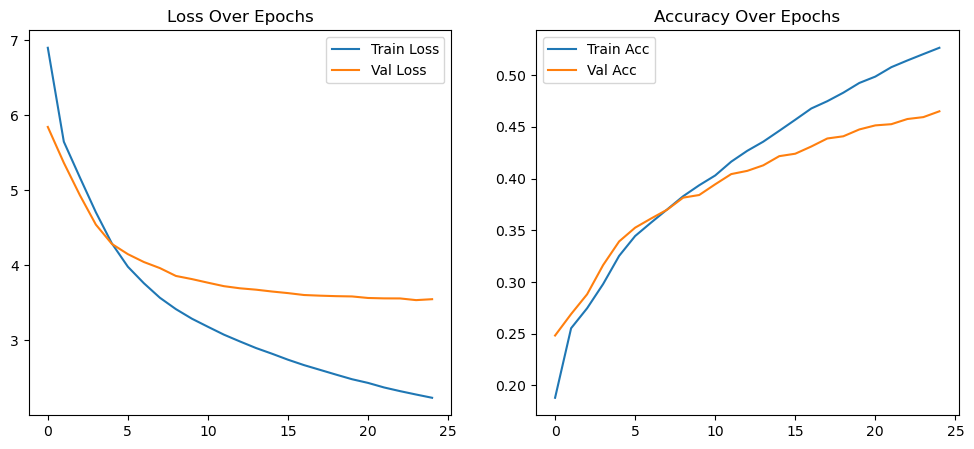

CPU times: user 2min 27s, sys: 558 ms, total: 2min 28s
Wall time: 1min 23s


In [49]:
%%time

history = train(
    model=model,
    train_loader=train_loader,  
    test_loader=test_loader,  
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=25,
    device=device
)

# GPU에 저장된 텐서 값들을 CPU용 숫자(float)로 변환
history['train_acc'] = [acc.cpu().item() if torch.is_tensor(acc) else acc for acc in history['train_acc']]
history['val_acc'] = [acc.cpu().item() if torch.is_tensor(acc) else acc for acc in history['val_acc']]

# 만약 Loss도 에러가 난다면 동일하게 처리 (보통 item()을 써서 이미 숫자일 확률이 높지만 안전하게)
history['train_loss'] = [loss.cpu().item() if torch.is_tensor(loss) else loss for loss in history['train_loss']]
history['val_loss'] = [loss.cpu().item() if torch.is_tensor(loss) else loss for loss in history['val_loss']]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Over Epochs'); plt.legend()

plt.show()

### 모델 평가

In [50]:
def decoder_inference(model, sentence, tokenizer, device='cpu'):
    # 토크나이저 ID 확인
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    MAX_LENGTH = 35  

    # 1. 전처리 및 인코더 입력 생성
    sentence = preprocess_sentence(sentence)
    enc_input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [END_TOKEN]
    enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)

    # 2. 디코더 입력 초기화 (시작 토큰만 포함)
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        for i in range(MAX_LENGTH):
            logits = model(enc_input, dec_input)
            
            # 마지막 단어의 예측값 추출
            last_step_logits = logits[:, -1, :]
            predicted_id = torch.argmax(last_step_logits, dim=-1)

            # 종료 토큰(EOS)이 나오면 멈춤
            if predicted_id.item() == END_TOKEN:
                break

            # 예측한 단어를 디코더 입력에 추가 (다음 단어 예측용)
            dec_input = torch.cat([dec_input, predicted_id.unsqueeze(0)], dim=1)

    # 3. 시작 토큰(<s>)을 제외하고 결과 반환
    return dec_input.squeeze(0).tolist()[1:]

def sentence_generation(model, sentence, tokenizer, device='cpu'):
    output_seq = decoder_inference(model, sentence, tokenizer, device=device)
    
    # SentencePiece의 decode는 리스트를 넣어주면 깨끗하게 문장으로 바꿔줍니다.
    predicted_sentence = tokenizer.decode(output_seq)

    print(f"입력 : {sentence}")
    print(f"출력 : {predicted_sentence}")
    return predicted_sentence


In [51]:
sentence = '안녕? 잘 지냈어?'
sentence_generation(model, sentence, sp, device)

입력 : 안녕? 잘 지냈어?
출력 : 잘 지냈어요 .


'잘 지냈어요 .'

In [57]:
sentence = '오늘 기분 어때?'
sentence_generation(model, sentence, sp, device)

입력 : 오늘 기분 어때?
출력 : 네 잘생겼어요 .


'네 잘생겼어요 .'

In [66]:
sentence = '오늘 너의 기분은?'
sentence_generation(model, sentence, sp, device)

입력 : 오늘 너의 기분은?
출력 : 저는 마음을 이어주는 위로봇입니다 .


'저는 마음을 이어주는 위로봇입니다 .'

In [60]:
sentence = '나는 오늘 슬퍼'
sentence_generation(model, sentence, sp, device)

입력 : 나는 오늘 슬퍼
출력 : 좋은 생각날 거예요 .


'좋은 생각날 거예요 .'

In [53]:
sentence = "오늘 회사에서 힘들었어"
sentence_generation(model, sentence, sp, device)

입력 : 오늘 회사에서 힘들었어
출력 : 잘 볼 수 있을 거예요 .


'잘 볼 수 있을 거예요 .'

In [54]:
sentence = "비 오는 날에는 어떤 음식이 좋을까?"
sentence_generation(model, sentence, sp, device)

입력 : 비 오는 날에는 어떤 음식이 좋을까?
출력 : 우산에 대해 생각해보세요 .


'우산에 대해 생각해보세요 .'

### 회고
- 공백 및 특수문자 처리, sentencePiece 토크나이징, 병렬 데이터 구축의 전과정을 진행하였고, **그 과정에서 최대 길이 확인, train,test 데이터셋을 나눌 때에 라벨 값을 이용하여 균등하게 분류하는 등의 과정을 따로 고안해서 시도 해볼 수 있었다**
- 트랜스포머 모델을 구현하고 한국어 챗봇 모델 학습을 정상적으로 진행하였다
   - 이 과정에서 모델 구현은 실습 코드를 활용했는데,
   - 처음에는 optimizer 정의를 lr 설정 없이 진행했더니 학습 잘 이뤄지지 않아 모델의 성능이 좋지 않았다`optimizer = optim.Adam(model.parameters(), betas=(0.9, 0.98), eps=1e-9)` 에서 
    - 그래서 `optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)` lr을 1.0으로 설정해주었고 아래의 결과를 얻을 수 있었다
       - Train - Avg Loss: 2.2352, Avg Acc: 0.5264
       - Val   - Avg Loss: 3.5493, Avg Acc: 0.4650
- 모델 평가
    - '안녕? 잘 지냈어?', '오늘 기분 어때?', '나는 오늘 슬퍼', '오늘 회사에서 힘들었어', '비 오는 날에는 어떤 음식이 좋을까?' 등의 한국어 질문(입력)을 넣고
    - 그에 대한 한국어 답변을 얻을 수 있었다
        - 아직 완벽한 대답을 하지는 못하지만,
        - `나는 오늘 슬퍼` - `좋은 생각날 거예요`
        - `힘들었어` - `잘 볼 수 있을 거에요` 라는 위로의 문장을
        - `비 오는 날` - `우산` 이라는 키워드를 대답하는 등
        - 문맥을 어느정도 파악하고 대답하는 것을 확인할 수 있었다